## Import Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import scipy.stats as stats
import warnings

## Unggah Dan Aggregasi Data

In [10]:
def load_and_aggregate_data(file_path):
    raw = pd.read_excel(file_path, header=None)
    header_row = raw[raw.astype(str).apply(lambda x: x.str.contains("Kode Produk", case=False)).any(axis=1)].index[0]
    df = pd.read_excel(file_path, header=header_row)
    df = df.loc[:, ~df.columns.duplicated()]
    
    week_cols = [col for col in df.columns if isinstance(col, (int, float)) or str(col).isdigit()]
    week_cols = sorted([int(col) for col in week_cols])

    df_long = df.melt(
        id_vars=["PRINC 1", "Kode Produk", "Produk"],
        value_vars=week_cols,
        var_name="Week",
        value_name="Sales"
    )

    start_date = pd.Timestamp("2024-01-01")
    df_long["Date"] = df_long["Week"].apply(lambda x: start_date + pd.to_timedelta((x - 1) * 7, unit="D"))
    df_long = df_long.sort_values(["Kode Produk", "Date"]).reset_index(drop=True)

    return df_long

## Membersihkan Data Sales

In [11]:
def clean_sales_data(df_long, product_name):
    df_product = df_long[df_long["Produk"] == product_name].copy()
    df_product = df_product.set_index("Date").sort_index()

    if df_product["Sales"].isna().sum() > 0:
        df_product["Sales"] = df_product["Sales"].interpolate(method="linear", limit_direction="both")

    if (df_product["Sales"] < 0).sum() > 0:
        df_product.loc[df_product["Sales"] < 0, "Sales"] = 0

    zero_count = (df_product["Sales"] == 0).sum()
    if 0 < zero_count < len(df_product) * 0.3:
        df_product["Sales"] = df_product["Sales"].replace(0, np.nan)
        df_product["Sales"] = df_product["Sales"].fillna(
            df_product["Sales"].rolling(window=3, center=True, min_periods=1).median()
        )

    Q1, Q3 = df_product["Sales"].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    df_product["Sales_Original"] = df_product["Sales"]
    df_product["Sales"] = df_product["Sales"].clip(lower=lower, upper=upper)

    return df_product

## Membuat Simulasi Waktu Penjualan

In [12]:
def create_time_features(df_product):
    df_product["Week_Number"] = range(1, len(df_product) + 1)
    df_product["Month"] = df_product.index.month
    df_product["Quarter"] = df_product.index.quarter
    df_product["MA_4"] = df_product["Sales"].rolling(window=4, min_periods=1).mean()
    df_product["MA_8"] = df_product["Sales"].rolling(window=8, min_periods=1).mean()
    df_product["STD_4"] = df_product["Sales"].rolling(window=4, min_periods=1).std()
    return df_product

## Cek & Buat Data Stasioner 

In [13]:
def check_stationarity(series):
    result = adfuller(series.dropna(), autolag='AIC')
    is_stationary = result[1] <= 0.05
    d_value = 0 if is_stationary else 1
    return is_stationary, d_value, result

In [14]:
def make_stationary(df_product):
    series = df_product["Sales"]
    is_stationary, d_value, _ = check_stationarity(series)

    if not is_stationary:
        df_product["Sales_Diff"] = series.diff()
        is_stat_diff, d_diff, _ = check_stationarity(series.diff().dropna())
        if is_stat_diff:
            return df_product, "Sales_Diff", 1
        df_product["Sales_Diff2"] = series.diff().diff()
        return df_product, "Sales_Diff2", 2

    return df_product, "Sales", 0

## Visualisasikan Data 

In [15]:
def visualize_cleaned_data(df_product, product_name):
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle(f'Data Analysis - {product_name}', fontsize=16, fontweight='bold')

    axes[0, 0].plot(df_product.index, df_product["Sales"], marker='o', linewidth=2)
    axes[0, 0].set_title('Weekly Sales')

    axes[0, 1].hist(df_product["Sales"], bins=15, color='skyblue', edgecolor='black')
    axes[0, 1].set_title('Sales Distribution')

    axes[1, 0].boxplot(df_product["Sales"], vert=False)
    axes[1, 0].set_title('Boxplot - Outlier Detection')

    rolling_mean = df_product["Sales"].rolling(window=4).mean()
    rolling_std = df_product["Sales"].rolling(window=4).std()
    axes[1, 1].plot(df_product.index, df_product["Sales"], alpha=0.5)
    axes[1, 1].plot(df_product.index, rolling_mean, label='Rolling Mean (4w)', color='red')
    axes[1, 1].plot(df_product.index, rolling_std, label='Rolling Std (4w)', color='orange')
    axes[1, 1].legend()
    axes[1, 1].set_title('Rolling Statistics')

    plot_acf(df_product["Sales"].dropna(), lags=20, ax=axes[2, 0])
    axes[2, 0].set_title('ACF')

    stats.probplot(df_product["Sales"].dropna(), dist="norm", plot=axes[2, 1])
    axes[2, 1].set_title('Q-Q Plot')

    plt.tight_layout()
    plt.show()

## Main Program

In [16]:
def main_preprocessing_pipeline(file_path, product_name):
    df_long = load_and_aggregate_data(file_path)
    df_product = clean_sales_data(df_long, product_name)
    df_product = create_time_features(df_product)
    df_product, series_col, d_value = make_stationary(df_product)
    visualize_cleaned_data(df_product, product_name)
    # Summary
    print("PREPROCESSING SELESAI - SUMMARY")
    print("="*70)
    print(f"✓ Jumlah data: {len(df_product)} minggu")
    print(f"✓ Missing values: {df_product['Sales'].isna().sum()}")
    print(f"✓ Nilai negatif: {(df_product['Sales'] < 0).sum()}")
    print(f"✓ Stasioneritas: {'YA' if d_value == 0 else f'Perlu differencing (d={d_value})'}")
    print(f"✓ Series untuk ARIMA: {series_col}")
    print(f"✓ Rekomendasi parameter d: {d_value}")
    print(f"\n[NEXT STEP] Data siap untuk ARIMA modeling dengan parameter d={d_value}")
    return df_product, series_col, d_value

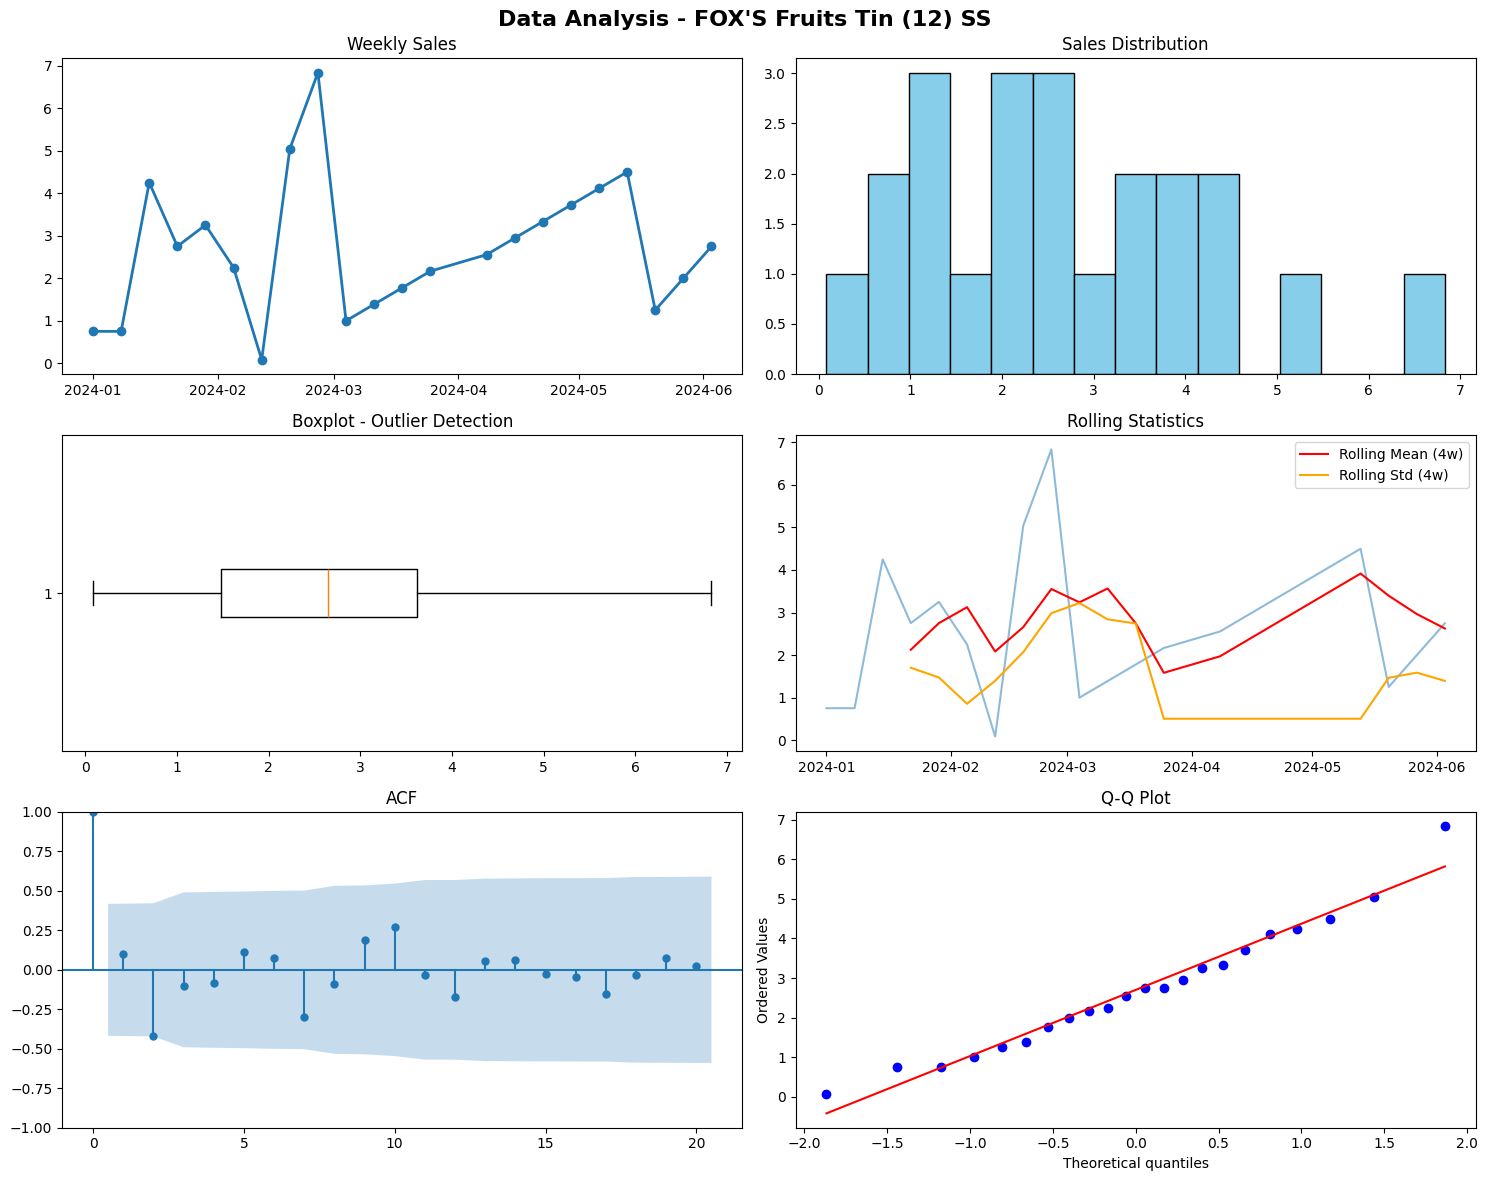

PREPROCESSING SELESAI - SUMMARY
✓ Jumlah data: 22 minggu
✓ Missing values: 0
✓ Nilai negatif: 0
✓ Stasioneritas: Perlu differencing (d=1)
✓ Series untuk ARIMA: Sales_Diff
✓ Rekomendasi parameter d: 1

[NEXT STEP] Data siap untuk ARIMA modeling dengan parameter d=1


In [ ]:
if __name__ == "__main__":
    file_path = "AVG 12W & 5W (W1-W40).xlsx"
    product_name = "FOX'S Fruits Tin (12) SS"
    df_cleaned, series_col, d_value = main_preprocessing_pipeline(file_path, product_name)